In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
df=pd.read_csv("cleaned.csv")
df.head()

,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [6]:
df = df.drop('Unnamed: 0', axis=1)

In [24]:
print("Data Shape:", df.shape)
print("=="*40)
print(df.info())
print("=="*40)
print("Missing Values:\n", df.isnull().sum())
print("=="*40)
print("Duplicates:", df.duplicated().sum())

Data Shape: (12205, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  object 
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14

Revenue
False    0.843671
True     0.156329
Name: proportion, dtype: float64


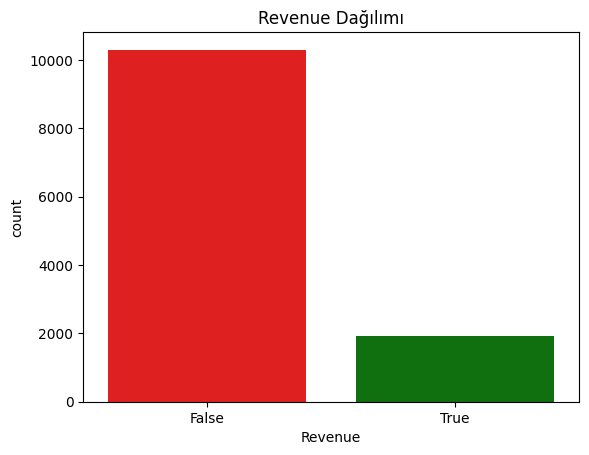

In [41]:
print(df['Revenue'].value_counts(normalize=True))

sns.countplot(data=df, x='Revenue', hue='Revenue', 
palette=['red', 'green'], 
legend=False
)

plt.title('Revenue Dağılımı')
plt.show()

Siteye giren kullanıcıların yaklaşık %84'ü ürün satın alımı yapmamış. **Veri, hedef değişken açısından dengesiz.** Modelin yanlı(biased) tahmin yapmaması ve daha iyi öğrenebilmesi için modele uygun ağırlıklandırma parametreleri(class_weight) kullanılabilir veya resampling methodları denenebilir, aynı zamanda model metrikleri de bu durum göz önünde bulundurularak incelenecek.

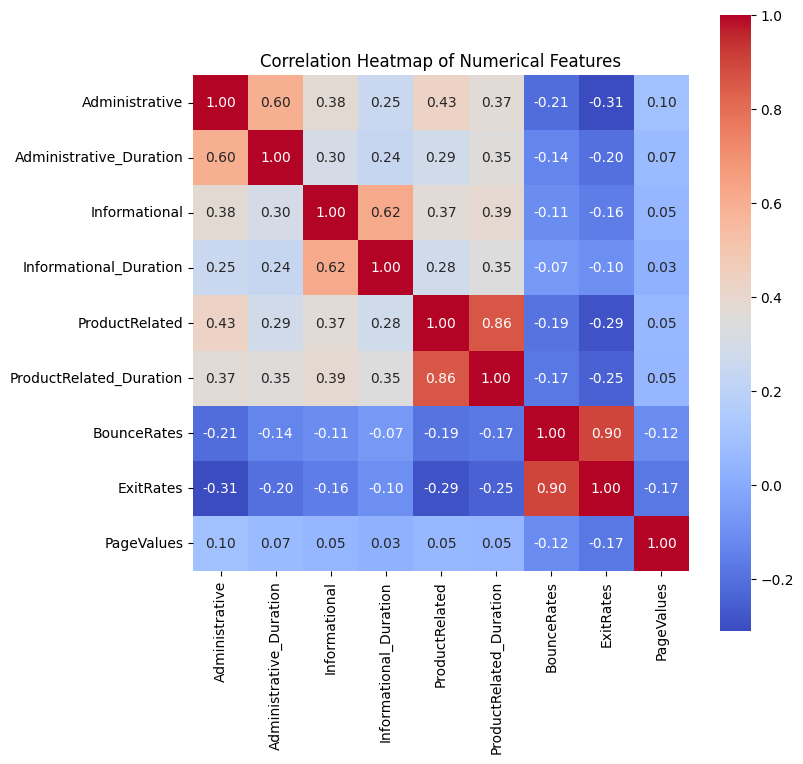

In [104]:
numeric_cols = ["Administrative", "Administrative_Duration", "Informational", "Informational_Duration",
                "ProductRelated", "ProductRelated_Duration", "BounceRates", "ExitRates", "PageValues"]
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [59]:
pairs = corr_matrix.abs().unstack()
sorted_pairs = pairs.sort_values(ascending=False)
sorted_pairs = sorted_pairs[sorted_pairs < 1.0]
print(sorted_pairs.drop_duplicates().head(10))

ExitRates                BounceRates                0.902144
ProductRelated_Duration  ProductRelated             0.860330
Informational_Duration   Informational              0.618648
Administrative_Duration  Administrative             0.600457
Administrative           ProductRelated             0.428305
ProductRelated_Duration  Informational              0.386052
Administrative           Informational              0.375256
ProductRelated           Informational              0.372572
Administrative           ProductRelated_Duration    0.371146
Administrative_Duration  ProductRelated_Duration    0.353583
dtype: float64


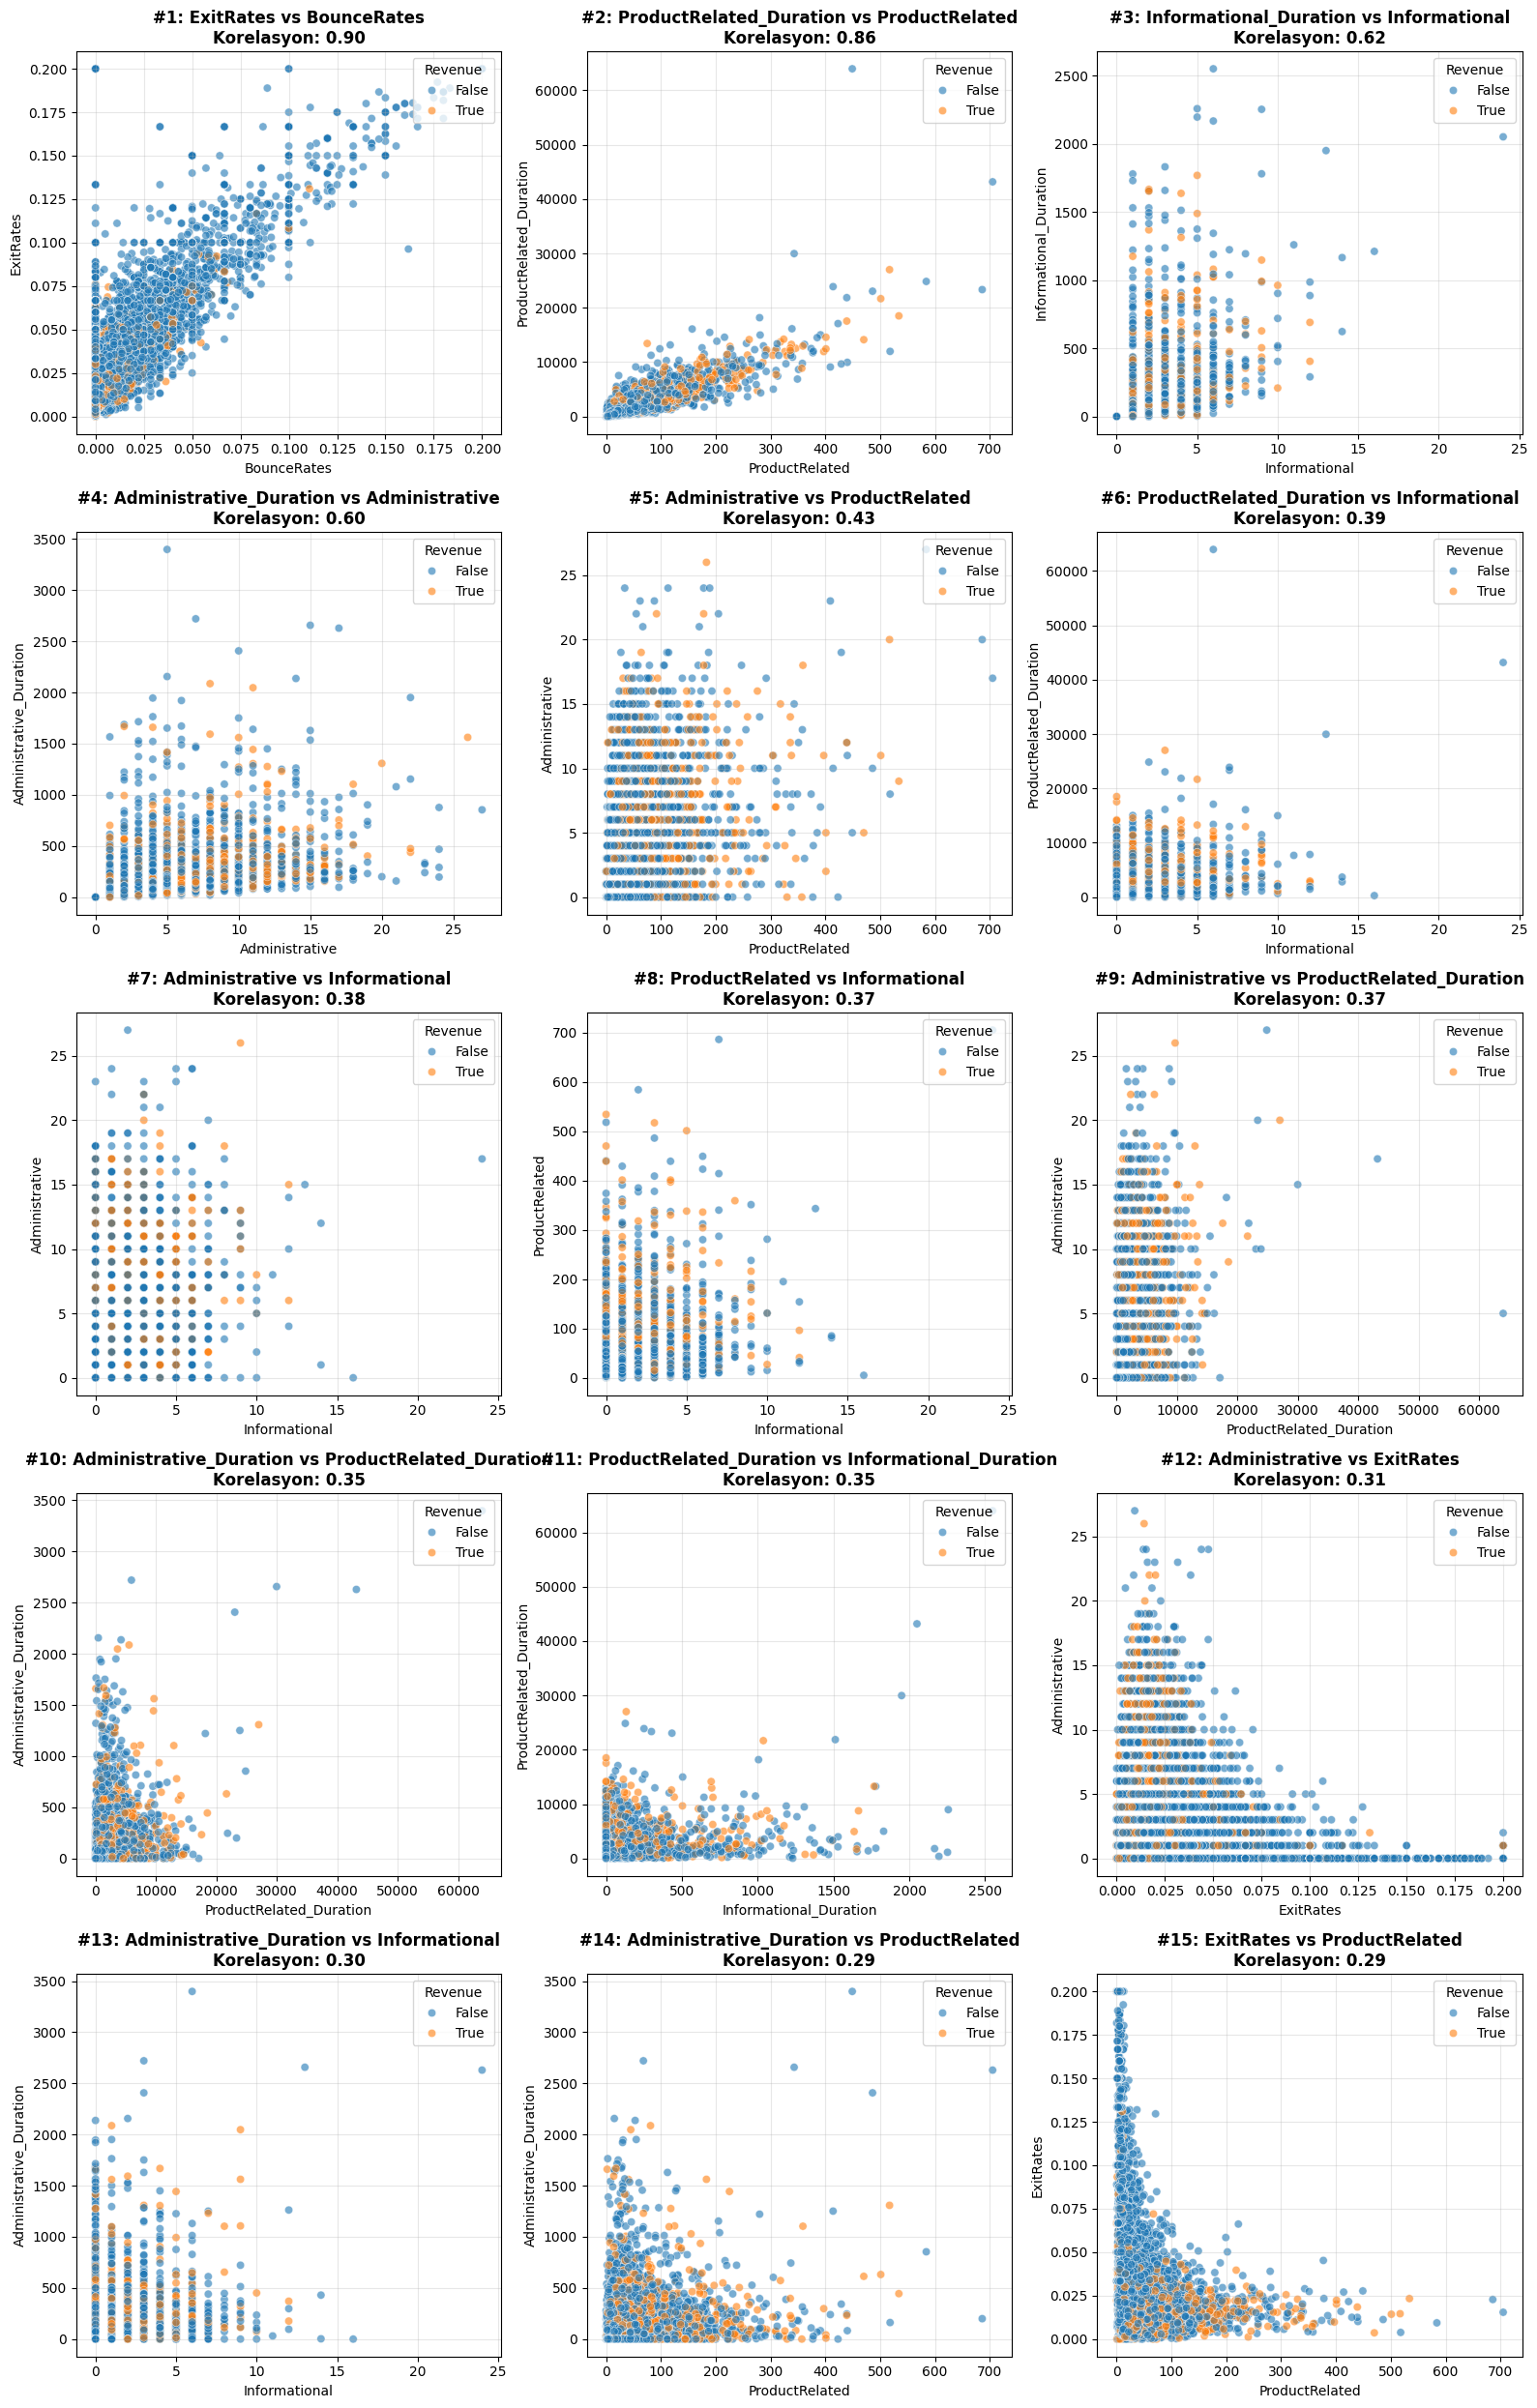

In [111]:
top_10_pairs = sorted_pairs.drop_duplicates().head(15)
fig, axes = plt.subplots(5, 3, figsize=(16, 25))
axes = axes.flatten() # Erişim kolaylığı için düzleştiriyoruz

for i, ((col1, col2), corr_value) in enumerate(top_10_pairs.items()):
    
    sns.scatterplot(
        data=df, 
        x=col2, 
        y=col1, 
        hue='Revenue', 
        palette={False: "#1f77b4", True: "#ff7f0e"}, # Mavi (False) - Turuncu (True)
        alpha=0.6, 
        ax=axes[i]
    )
    
    axes[i].set_title(f'#{i+1}: {col1} vs {col2}\nKorelasyon: {corr_value:.2f}', fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(loc='upper right', title='Revenue')

plt.tight_layout()
plt.show()

Birbirleriyle mantıksal olarak ilişki olması beklenen özellikler (ProductRelated/ProductRelated_Duration veya bounce/exit rates gibi) arasında yüksek korelasyon mevcut. Feature selection aşamasında dikkat edilecek.
Bunun dışında, google analytics sayfa etkileşimi metriklerinin birbirleriyle orta düzeyde ilişkileri olduğu söylenebilir. (0.30-0.43)



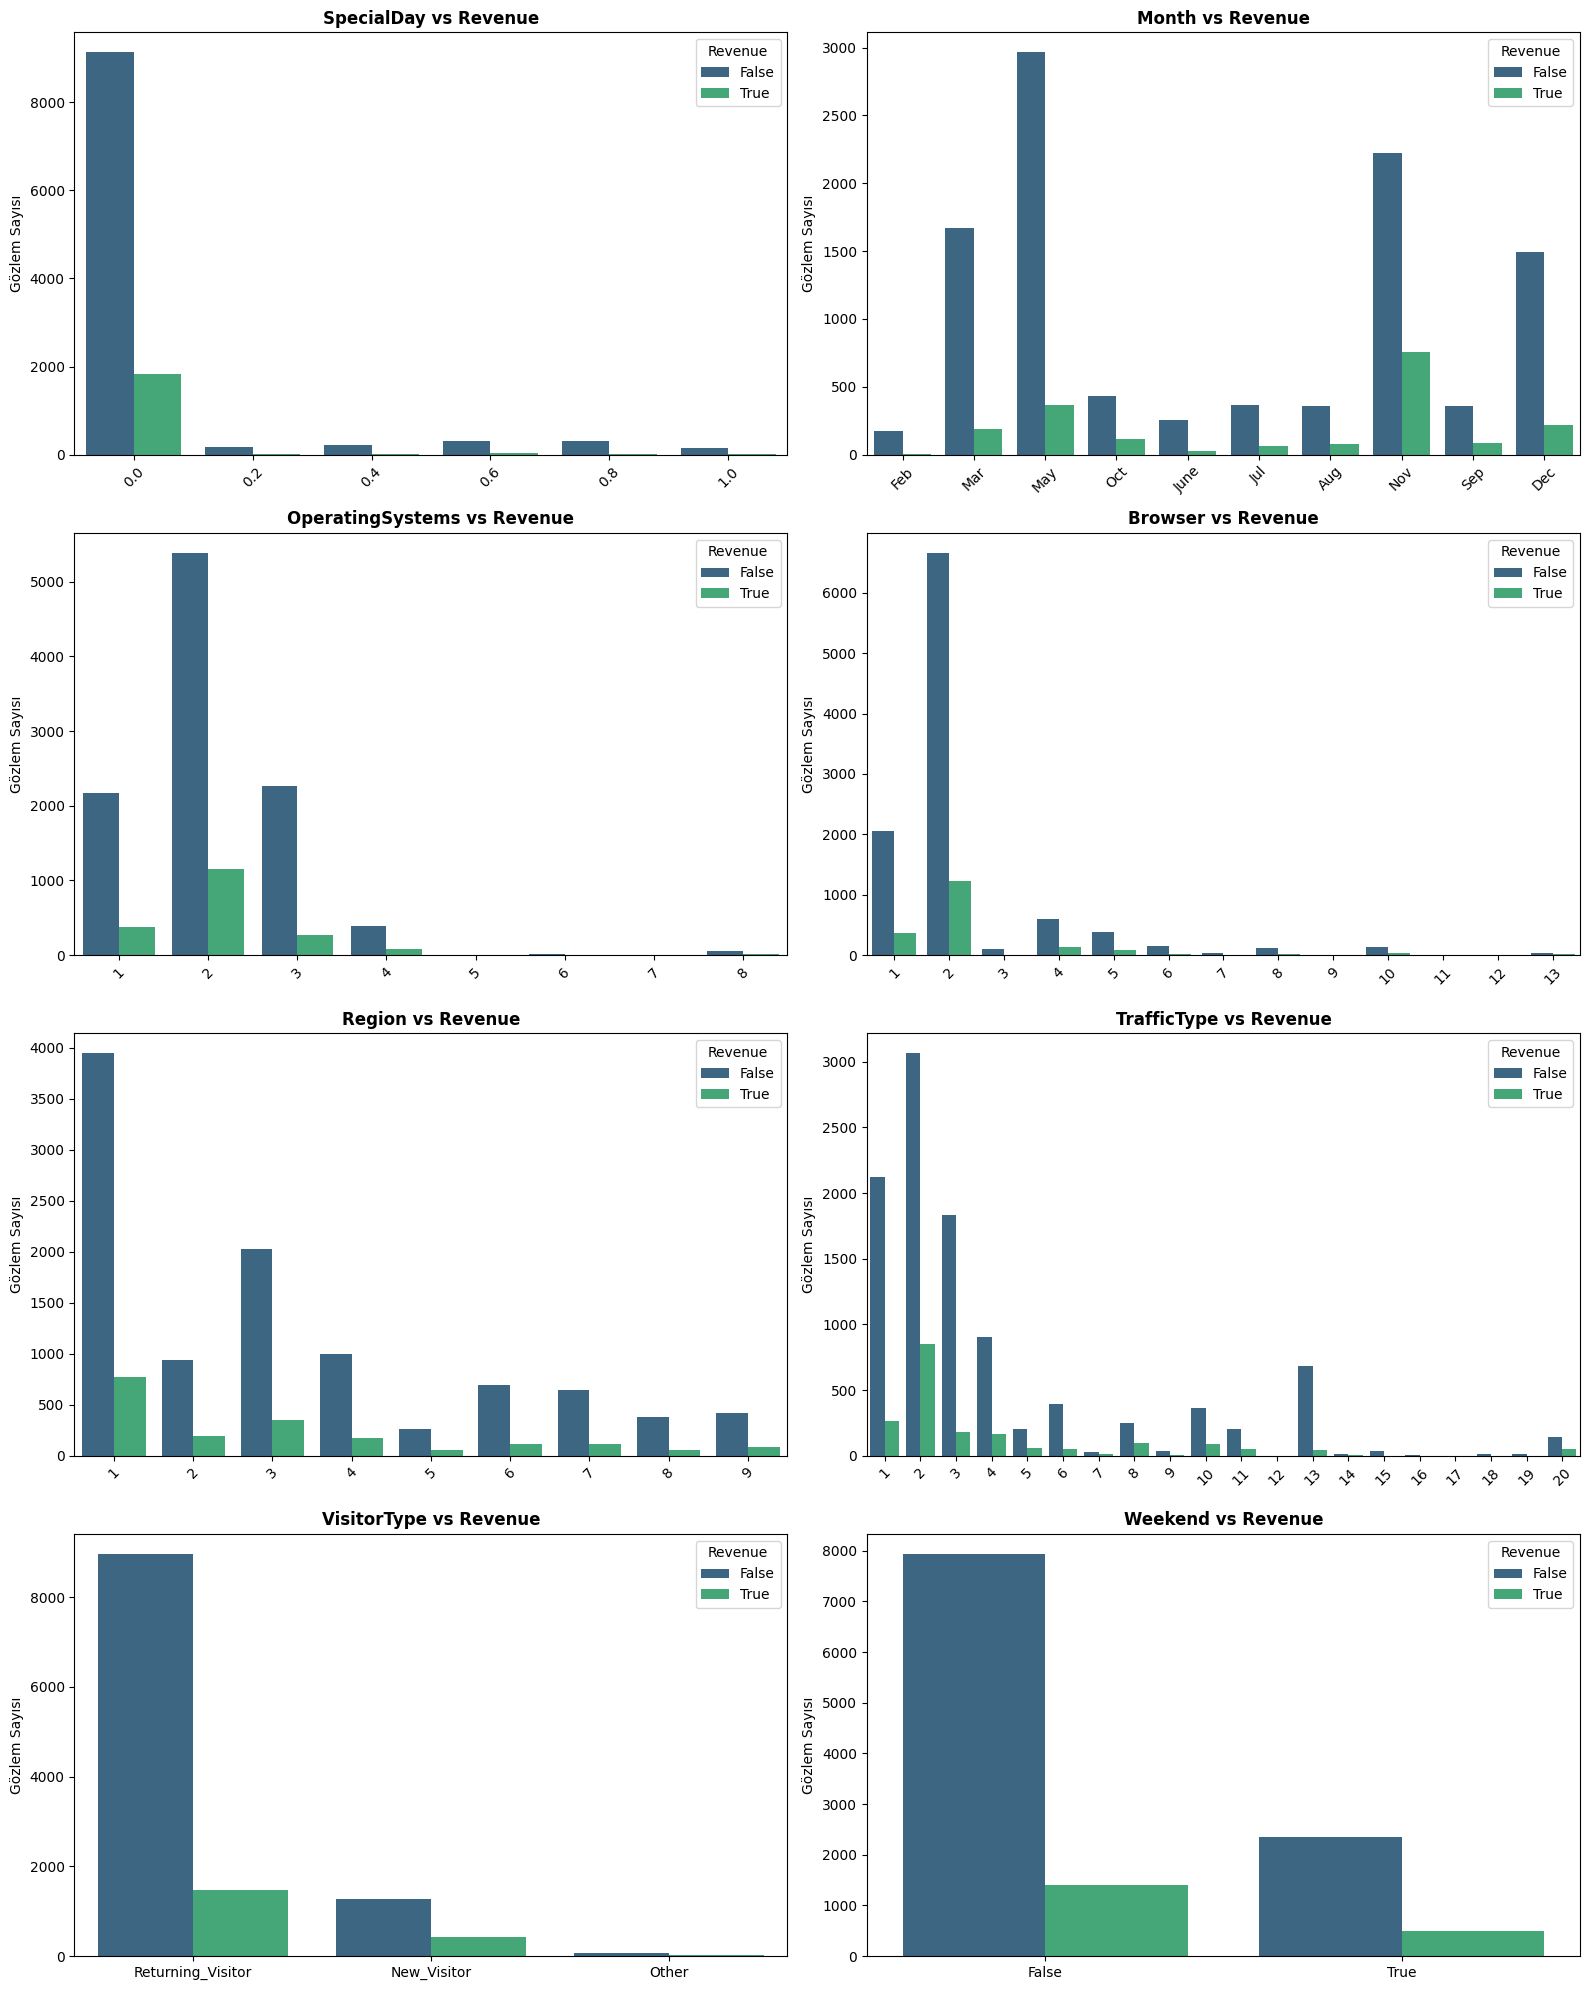

In [85]:
cat_cols = ["SpecialDay", "Month", "OperatingSystems", "Browser", 
            "Region", "TrafficType", "VisitorType", "Weekend"]

n_cols = 2
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()

# Her bir değişken için döngü
for i, col in enumerate(cat_cols):
    if i < len(axes):
        sns.countplot(data=df, x=col, hue='Revenue', ax=axes[i], palette='viridis')
        
        axes[i].set_title(f'{col} vs Revenue', fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Gözlem Sayısı')
        axes[i].legend(title='Revenue', loc='upper right')
        
        if df[col].nunique() > 5:
            axes[i].tick_params(axis='x', rotation=45)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

- İlk 3 Trafik Kaynağından gelen kullanıcılar en yüksek ziyaret ve satış sayılarına sahiptir.
- Mart,Mayıs,Kasım ve Aralık tarihlerinde en yüksek ziyaret ve satış sayılarına ulaşılmış. Dünya kadınlar günü, anneler günü, black friday gibi dönemlerde yapılan özel kampanya dönemlerinde satışlar artmış.

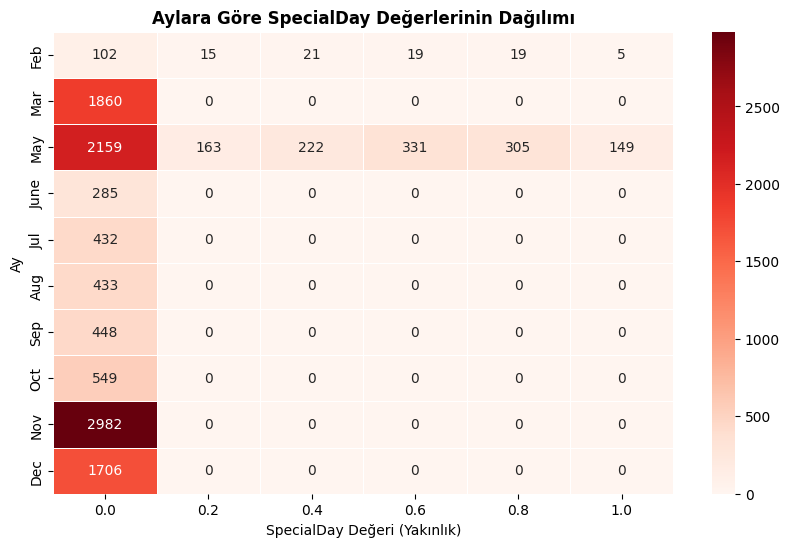

In [89]:
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
crosstab = pd.crosstab(df['Month'], df['SpecialDay'])
crosstab = crosstab.reindex(month_order)

plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Reds', linewidths=0.5)
plt.title('Aylara Göre SpecialDay Değerlerinin Dağılımı', fontweight='bold')
plt.xlabel('SpecialDay Değeri (Yakınlık)')
plt.ylabel('Ay')
plt.show()

- Çarpraz tablo incelendiğinde, "SpecialDay" değişkeninin yalnızca Şubat ve Mayıs ayındaki özel günleri kapsadığı görülmekte. Muhtemelen Sevgililer Günü ve Anneler Günü olarak tanımlanmış.
- Dikkat çekici bir detay ise, Black Friday'in özel gün olarak tanımlanmamış olması. Kasım ayında indirim yapılmış olsa da (En yüksek satış ve ziyaret değerlerinin kasımda olması bunu gösteriyor) bu dönem veri setinde özel olarak kodlanmamış. 
- Special Day yalnızca hediyeleşme günlerini (Şubat,Mayıs) kapsıyor.

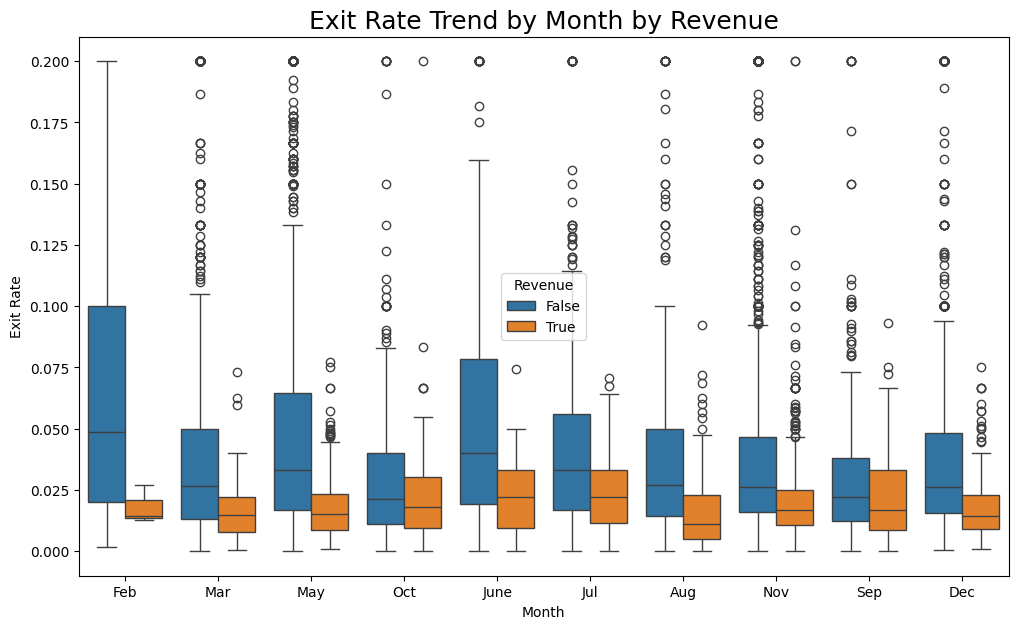

In [96]:

plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='Month', y='ExitRates', hue='Revenue',
            palette={False: "#1f77b4", True: "#ff7f0e"})

plt.title('Exit Rate Trend by Month by Revenue', fontsize=18)
plt.xlabel("Month")
plt.ylabel("Exit Rate")
plt.legend(title="Revenue")
plt.show()


- Satın alım yapan kullanıcıların çıkış yapma oranı, alım yapmayanlara göre -bekleneceği üzere- çok daha düşük bir dağılıma sahip gibi görünüyor. Aynı zamanda satın alım yapan kullanıcıların çok daha düşük bir dağılım gösterdiği ve birbirleriyle homojen olduğunu söylemek mümkün.
- Satın alım yapmayan kullanıcılar ise çıkış yapma oranı bakımından sağa çarpık ve geniş bir dağılıma sahip, bunun yanı sıra satın almayanlar arasında çok yüksek çıkış oranına sahip kullanıcılar da aykırı değerlere sebep olmuş. Bu aykırı değerler özellikle kampanya aylarında en büyük sıklıklara sahip (mayıs,kasım). Bu durum kampanyayı duyarak giriş yapan, sonrasında karar veremeyen/beklentisi karşılanamayan müşterilerden kaynaklı olabilir.
  

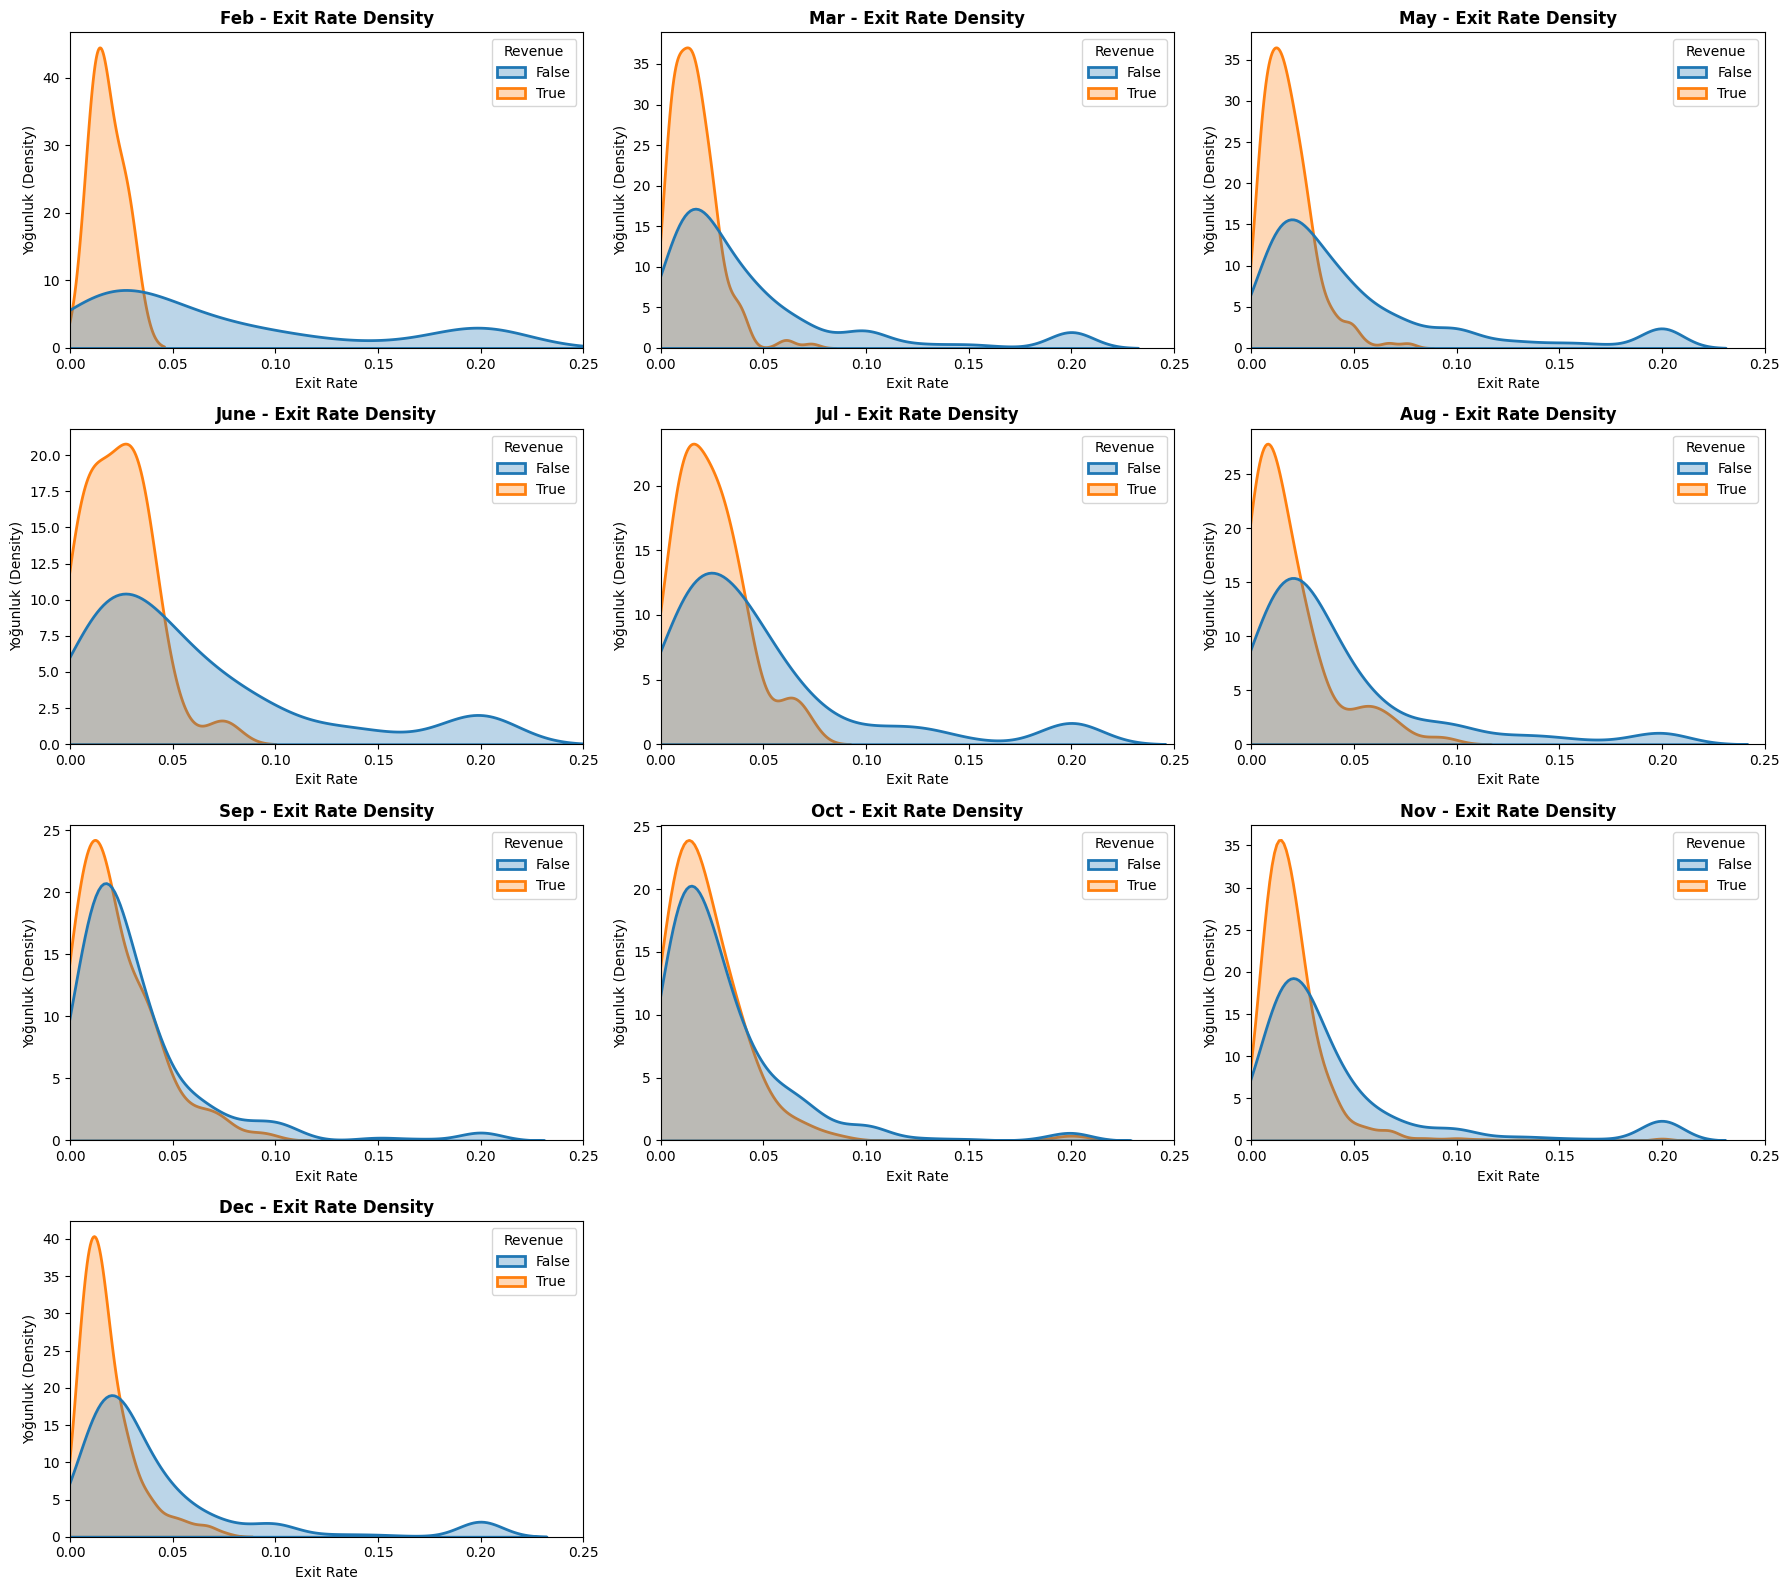

In [102]:
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

n_cols = 3
n_rows = math.ceil(len(month_order) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten() # Döngüde kolay gezmek için düzleştir

for i, month in enumerate(month_order):
    month_data = df[df['Month'] == month]
    
    sns.kdeplot(data=month_data, x='ExitRates', hue='Revenue', 
                ax=axes[i], palette={False: "#1f77b4", True: "#ff7f0e"},
                fill=True, alpha=0.3, linewidth=2, common_norm=False)
    
    axes[i].set_title(f'{month} - Exit Rate Density', fontweight='bold')
    axes[i].set_xlabel('Exit Rate')
    axes[i].set_ylabel('Yoğunluk (Density)')
    axes[i].set_xlim(0, 0.25) # Exit Rate genelde 0-0.2 arasındadır, odaklanalım
    
# 4. Boş kalan subplotları gizle
for j in range(len(month_order), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

- Özellikle Feb(Şubat) ayında, sessionı satın alım ile sonuçlanan kullanıcılar direkt olarak almak istedikleri/karar verdikleri ürünler bazında gezinti yapmış. Exit rate 0.00-0.05 gibi dar bir aralıkta sivri bir dağılımla yoğunlaşmış.
- Feb, Mar, May ayları için 0.05'den yüksek exit rate'ine sahip kullanıcıların neredeyse hepsi "Revenue = False" sınıfındadır. Diğer aylar için ise bu sınır 0.10 olarak belirlenebilir. Exit Rate'deki bu net ayırt edici eşik modelin eğitilmesine yüksek katkı sağlayacak gibi görünüyor.  

## Baseline Model

In [113]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt


df_model = df.copy()

# specialday'i binary hale getiriyoruz.
df_model['Is_SpecialDay'] = (df_model['SpecialDay'] > 0).astype(int)
df_model.drop('SpecialDay', axis=1, inplace=True)

# multicollineraty için
df_model.drop('BounceRates', axis=1, inplace=True)

df_model['Revenue'] = df_model['Revenue'].astype(int)


#encoding
cat_cols = ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']

df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)


X = df_model.drop('Revenue', axis=1)
y = df_model['Revenue']

# Stratify=y örneklemin kitleyi sınıfların oranı bakımından doğru temsil etmesi için
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Hazırlık Tamamlandı.")
print(f"Eğitim Seti Boyutu: {X_train_scaled.shape}")
print(f"Test Seti Boyutu: {X_test_scaled.shape}")

Hazırlık Tamamlandı.
Eğitim Seti Boyutu: (9764, 68)
Test Seti Boyutu: (2441, 68)


In [119]:
print(f"Total size: {len(X)}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

print("\n" + "-"*30 + "\n")

print(f"Train size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Target distribution:\n{y_train.value_counts(normalize=True)}")

print("\n" + "-"*30 + "\n")

print(f"Test size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"Target distribution:\n{y_test.value_counts(normalize=True)}")

Total size: 12205
Target distribution:
Revenue
0    0.843671
1    0.156329
Name: proportion, dtype: float64

------------------------------

Train size: 9764 (80.0%)
Target distribution:
Revenue
0    0.843712
1    0.156288
Name: proportion, dtype: float64

------------------------------

Test size: 2441 (20.0%)
Target distribution:
Revenue
0    0.843507
1    0.156493
Name: proportion, dtype: float64



--- BASELINE MODEL PERFORMANSI ---

              precision    recall  f1-score   support

           0       0.96      0.86      0.90      2059
           1       0.51      0.80      0.62       382

    accuracy                           0.85      2441
   macro avg       0.73      0.83      0.76      2441
weighted avg       0.89      0.85      0.86      2441

ROC-AUC Skoru: 0.9082


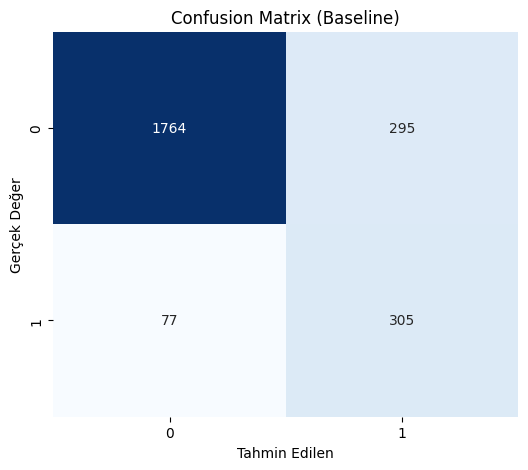

In [114]:
# class_weight='balanced'
baseline_model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)

baseline_model.fit(X_train_scaled, y_train)

y_pred = baseline_model.predict(X_test_scaled)
y_prob = baseline_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- BASELINE MODEL PERFORMANSI ---\n")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Skoru: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Baseline)')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.show()